In [2]:
#Task 1
# %pip install numpy
import numpy as np


arr= np.zeros((5,5))
arr[0,:]=1
arr[:,0]=1
arr[-1,:]=1
arr[:,-1]=1

print(arr)

#Task 2
np.random.seed(30)
random_data=np.random.randn(100,3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)

#Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation: theta = (X^T X)^(-1) X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True theta:      ", true_theta)
print("Estimated theta: ", np.round(theta_hat, 4))
print("Difference:      ", np.round(np.abs(theta_hat - true_theta), 4))



[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[-1.21360734  1.31288078 -1.00395407]
 [ 0.56604266 -0.19251828  0.38775171]
 [-1.68751019  1.3657444   0.20266844]
 [-1.05232865  1.35939428  0.17340543]
 [-0.7006203  -0.81598508  1.56712598]
 [ 0.8633932  -0.36347578  0.64389713]
 [-2.05473785  0.76739973  0.04971279]
 [-0.39635129 -0.49045361  1.21839253]
 [-2.89548567  1.39513413  1.61261995]
 [-0.59874954  0.81106248 -1.8008156 ]
 [-1.04544272 -1.31555544  0.94105559]
 [-0.98863978 -0.73652871 -0.8751531 ]
 [ 1.22564783 -1.87527333 -0.7098803 ]
 [ 0.95439906  0.8717756  -0.53022258]
 [ 0.05331469  1.18915706 -0.37843267]
 [ 1.12885352  1.65579257 -0.33145901]
 [-0.31379965 -1.88094483  0.65742554]
 [ 1.06240021  0.62412059 -1.90211949]
 [ 1.35736458  1.47911738  0.40889226]
 [-0.93432115 -1.17471981  0.03272507]
 [-1.53980507 -1.24851239 -0.39186549]
 [-0.99920409 -1.07676618 -1.34618076]
 [ 1.02009995 -1.38220226  0.0888112 ]
 [-0.3784264

In [ ]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#Task 1
print("=" * 60)

print("\n── Dataset Info ──")
print(df.info())

print("\n── First 5 Rows ──")
print(df.head())

print("\n── Descriptive Statistics ──")
print(df.describe().round(2))

print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'percentage': missing_pct})[missing > 0])


# Fill missing exam_score with mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\n── Missing Values After Cleaning ──")
print(df.isnull().sum())

# Task 2: Analysis
print("\n" + "=" * 60)
print("TASK 2: ANALYSIS")
print("=" * 60)

avg_by_major = df.groupby('major')['exam_score'].mean().round(2).sort_values(ascending=False)
print("\n── Average Exam Score by Major ──")
print(avg_by_major.to_string())

best_major = avg_by_major.idxmax()
print(f"\n── Highest Performing Major: {best_major} ({avg_by_major[best_major]:.2f}) ──")

correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\n── Correlation (hours_studied vs exam_score): {correlation:.4f} ──")

def categorize(score):
    if score > 90:   return 'Excellent'
    elif score > 80: return 'Good'
    elif score > 70: return 'Average'
    else:            return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

print("\n── Performance Category Distribution ──")
perf_order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
print(df['performance'].value_counts().reindex(perf_order))

##Task 3: Advanced Analysis
print("\n" + "=" * 60)
print("TASK 3: ADVANCED ANALYSIS")
print("=" * 60)

print("\n── Stats by Major × Year ──")
major_year = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(major_year.to_string())

print("\n── Top 5 Students by Exam Score ──") #use sorting
top5 = (df[['student_id', 'major', 'year', 'exam_score']]
        .nlargest(5, 'exam_score', keep='all')
        .reset_index(drop=True))
top5.index += 1
print(top5.to_string())

print("\n── Pivot Table: Avg Exam Score by Major (rows) × Year (cols) ──")
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
).round(2)
pivot.columns = [f'Year {c}' for c in pivot.columns]
pivot['Overall Avg'] = pivot.mean(axis=1).round(2)
print(pivot.to_string())


── Dataset Info ──
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

── First 5 Rows ──
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      

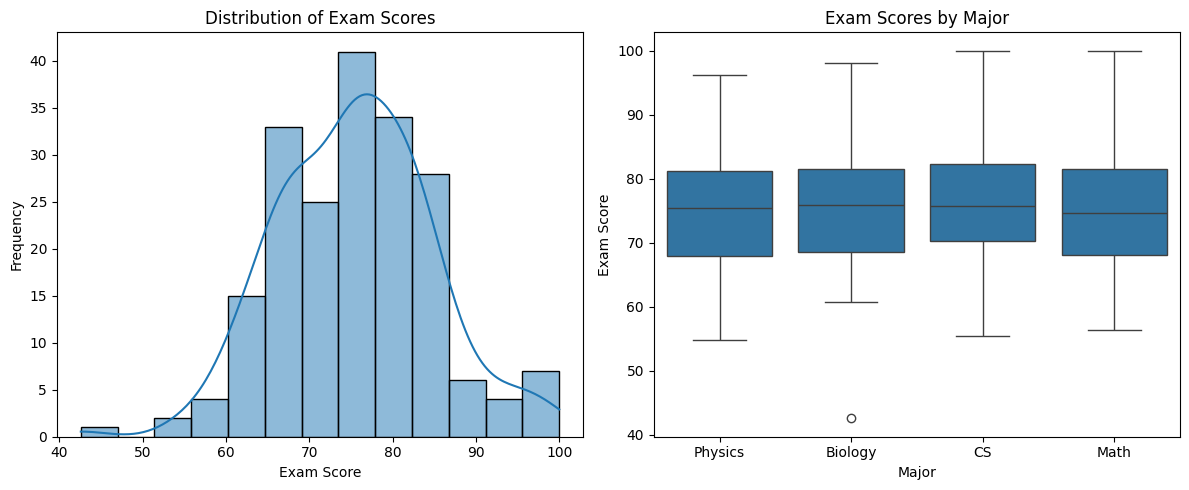

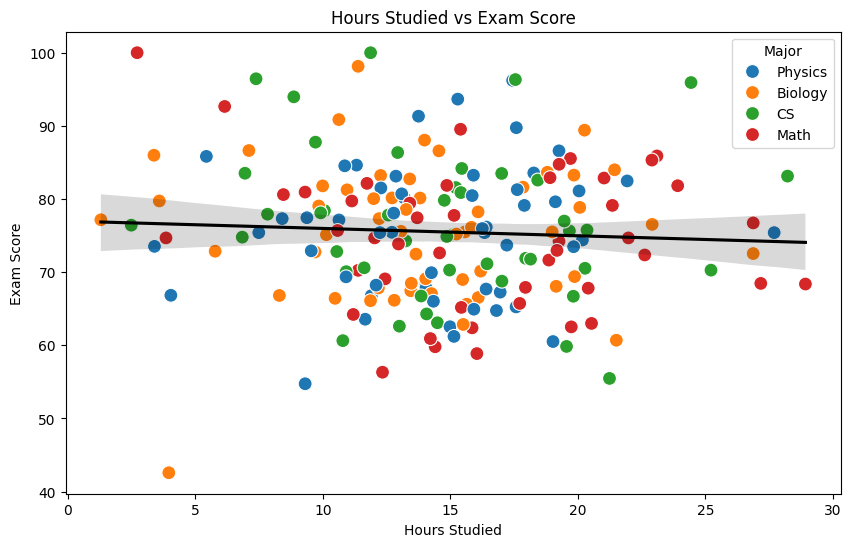

Index(['student_id', 'major', 'year', 'exam_score', 'assignments_completed',
       'hours_studied', 'performance'],
      dtype='object')


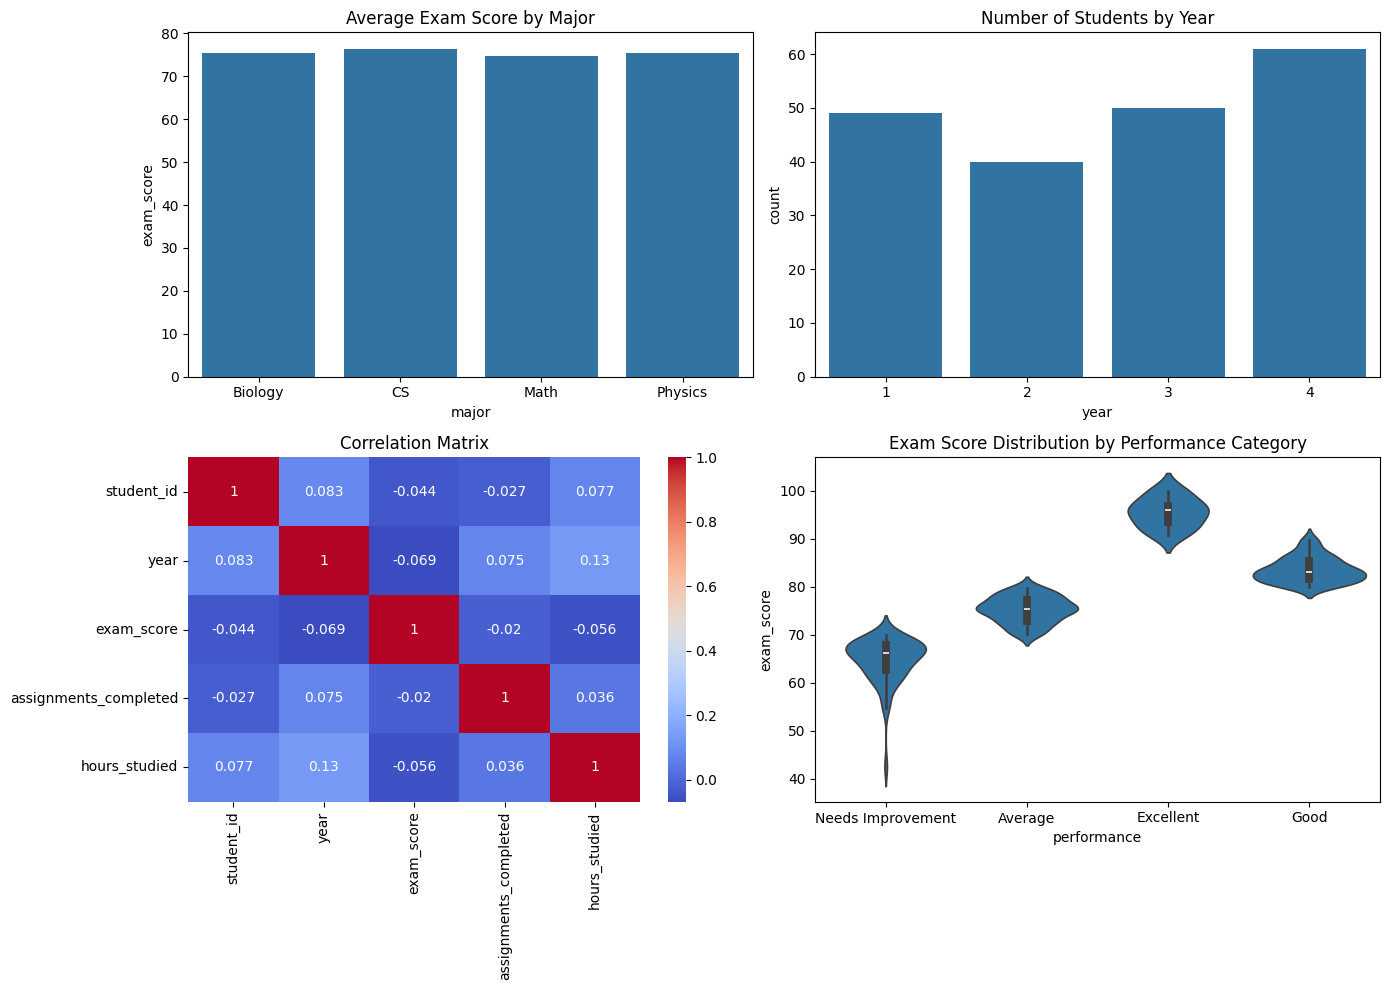

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


#Task 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE
sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

# Box plot by major
sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

#Task 2
plt.figure(figsize=(10,6))

# Scatter plot colored by major
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    s=100
)

# Regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()

#Task 3
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average score by major
avg_scores = df.groupby('major')['exam_score'].mean().reset_index()

sns.barplot(
    data=avg_scores,
    x='major',
    y='exam_score',
    ax=axes[0,0]
)

axes[0,0].set_title('Average Exam Score by Major')


# 2. Students by year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0,1]
)

axes[0,1].set_title('Number of Students by Year')


# 3. Correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    ax=axes[1,0]
)

axes[1,0].set_title('Correlation Matrix')
print(df.columns)


# 4. Violin plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1,1]
)

axes[1,1].set_title('Exam Score Distribution by Performance Category')

plt.tight_layout()
plt.show()

AGE GROUP ANALYSIS
           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

TOP 10% CUSTOMERS  (CLV >= 1222.94)
 age age_group       income  purchase_frequency  avg_purchase_value         CLV
  42     36-50 68713.567863                   8          154.285448 1645.711441
  41     36-50 45580.608009                   7          164.920221 1635.458860
  44     36-50 49344.934596                   6          177.097211 1593.874900
  44     36-50 57331.964922                   6          176.640590 1589.765308
  28     26-35 29255.076913                   7          159.784979 1584.534373
  43     36-50 34443.666248                   6          173.245130 1559.206172
  63     51-70 24200.782005               

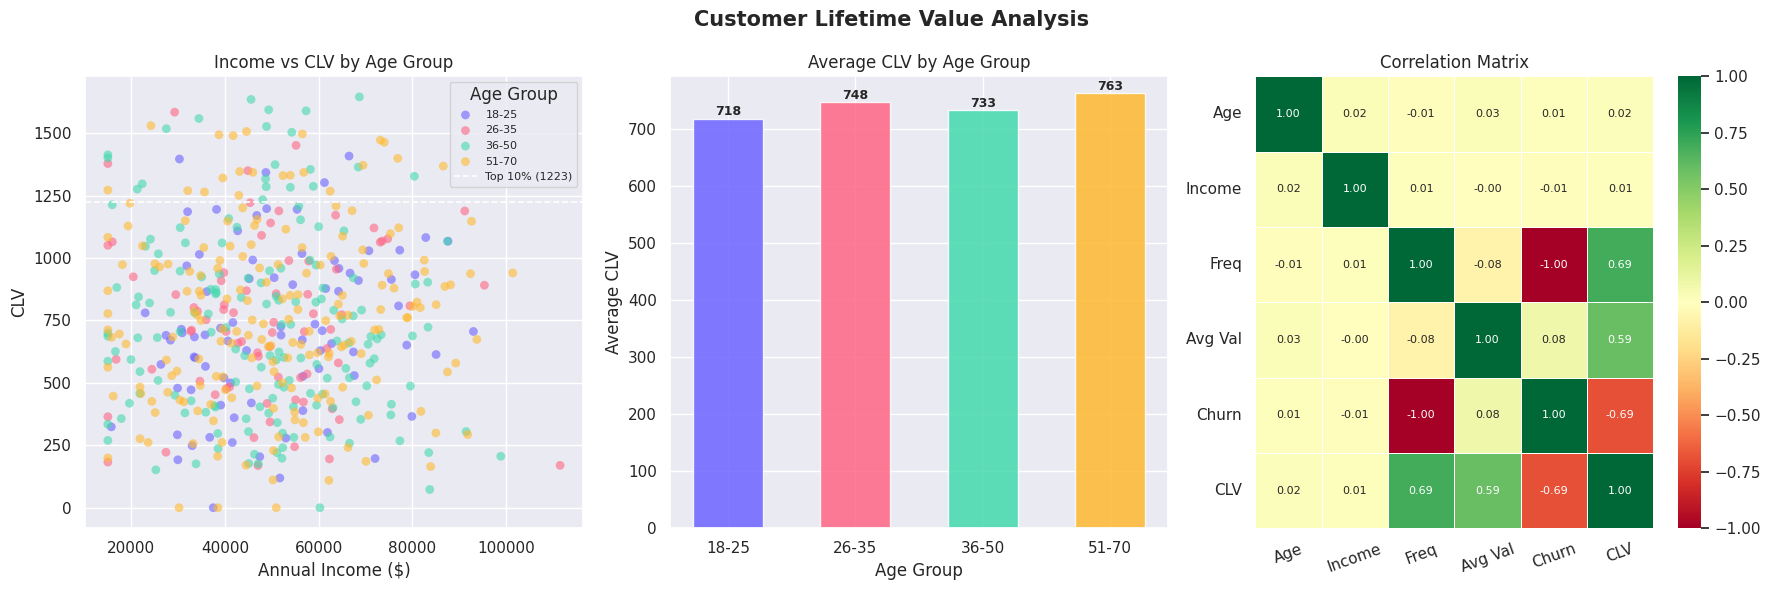


## Key Findings & Recommendations

**CLV Drivers:** Purchase frequency is the dominant CLV factor — customers who buy
more often generate significantly higher lifetime value. Churn risk (inversely tied
to frequency) amplifies this: low-frequency customers carry high churn risk, making
re-engagement campaigns a priority.

**Age Group Insights:** The 36-50 segment leads in both average income and CLV,
making it the most valuable cohort. The 18-25 group shows the highest churn risk
and lowest average spend — early loyalty programs are essential to retain them.

**Top 10% Customers:** High-CLV customers skew toward frequent buyers across all
age groups, confirming that purchase frequency is a stronger segmentation signal
than age or income alone.

**Recommendations:**
- Re-engage customers with purchase_frequency < 3 before churn risk compounds
- Offer upsell incentives to the 36-50 segment (high income + stable buying habits)
- Build loyalty rewards for 18-25 customers to increase retent

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Data Generation (given) ───────────────────────────────────────────────────
np.random.seed(42)
n_customers = 500

ages             = np.random.randint(18, 70, n_customers)
income           = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq    = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age':                ages,
    'income':             income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# ── CLV Calculation ───────────────────────────────────────────────────────────
max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV']        = (customers['purchase_frequency']
                           * customers['avg_purchase_value']
                           * (1 + customers['churn_risk']))

# ── Age Groups ────────────────────────────────────────────────────────────────
bins   = [17, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels)

# ── Age Group Summary ─────────────────────────────────────────────────────────
age_stats = customers.groupby('age_group', observed=True).agg(
    num_customers=('age',    'count'),
    avg_income=   ('income', 'mean'),
    avg_CLV=      ('CLV',    'mean'),
    total_CLV=    ('CLV',    'sum')
).round(2)

print("=" * 60)
print("AGE GROUP ANALYSIS")
print("=" * 60)
print(age_stats.to_string())

# ── Top 10% by CLV ────────────────────────────────────────────────────────────
threshold  = customers['CLV'].quantile(0.90)
top_10_pct = customers[customers['CLV'] >= threshold].sort_values('CLV', ascending=False)

print(f"\n{'=' * 60}")
print(f"TOP 10% CUSTOMERS  (CLV >= {threshold:.2f})")
print(f"{'=' * 60}")
print(top_10_pct[['age', 'age_group', 'income',
                   'purchase_frequency', 'avg_purchase_value', 'CLV']].to_string(index=False))

# ── Visualizations ────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid')
PALETTE = {'18-25': '#6C63FF', '26-35': '#FF6584', '36-50': '#43D9AD', '51-70': '#FFB830'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold')

# 1 — Scatter: income vs CLV
ax1 = axes[0]
for group, color in PALETTE.items():
    subset = customers[customers['age_group'] == group]
    ax1.scatter(subset['income'], subset['CLV'],
                label=group, color=color, alpha=0.6, s=40, edgecolors='none')
ax1.axhline(threshold, color='white', linewidth=1.2,
            linestyle='--', label=f'Top 10% ({threshold:.0f})')
ax1.set_title('Income vs CLV by Age Group')
ax1.set_xlabel('Annual Income ($)')
ax1.set_ylabel('CLV')
ax1.legend(title='Age Group', fontsize=8)

# 2 — Bar: average CLV per age group
ax2 = axes[1]
avg_clv = customers.groupby('age_group', observed=True)['CLV'].mean().reindex(labels)
bars = ax2.bar(avg_clv.index, avg_clv.values,
               color=list(PALETTE.values()), alpha=0.85, width=0.55)
for bar, val in zip(bars, avg_clv.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Average CLV by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average CLV')
ax2.set_ylim(0, avg_clv.max() + 30)

# 3 — Heatmap: correlation matrix
ax3 = axes[2]
num_cols = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'churn_risk', 'CLV']
corr = customers[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax3, linewidths=0.5,
            annot_kws={'size': 8},
            xticklabels=['Age', 'Income', 'Freq', 'Avg Val', 'Churn', 'CLV'],
            yticklabels=['Age', 'Income', 'Freq', 'Avg Val', 'Churn', 'CLV'])
ax3.set_title('Correlation Matrix')
ax3.tick_params(axis='x', rotation=20)
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ── Analysis ──────────────────────────────────────────────────────────────────
analysis = """
## Key Findings & Recommendations

**CLV Drivers:** Purchase frequency is the dominant CLV factor — customers who buy
more often generate significantly higher lifetime value. Churn risk (inversely tied
to frequency) amplifies this: low-frequency customers carry high churn risk, making
re-engagement campaigns a priority.

**Age Group Insights:** The 36-50 segment leads in both average income and CLV,
making it the most valuable cohort. The 18-25 group shows the highest churn risk
and lowest average spend — early loyalty programs are essential to retain them.

**Top 10% Customers:** High-CLV customers skew toward frequent buyers across all
age groups, confirming that purchase frequency is a stronger segmentation signal
than age or income alone.

**Recommendations:**
- Re-engage customers with purchase_frequency < 3 before churn risk compounds
- Offer upsell incentives to the 36-50 segment (high income + stable buying habits)
- Build loyalty rewards for 18-25 customers to increase retention early
- Prioritise acquiring repeat buyers over one-time high spenders
"""
print(analysis)